
# Self-Verifying Tutor Notebook
This Colab-ready notebook builds a **Self-Verifying AI Tutor** benchmark with:
- Google Drive export
- benchmark generation
- evidence-grounded tutoring
- citation extraction and citation validation
- fact validation
- self-correction loop
- hallucination, abstention, calibration, and overconfident-error metrics
- a **Self-Verification Score (SVS)**
- publication-ready figures and CSV tables

The notebook runs in **simulation mode by default** so it works immediately.  
It also contains hooks for replacing the simulator with real API calls later.


In [ ]:

import os, json, math, random, re
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42
random.seed(SEED)



## 1. Mount Google Drive and prepare output folders
When run in Colab, all outputs are saved under:
`MyDrive/Self_Verifying_Tutor_Benchmark`


In [ ]:

OUTPUT_DIR_LOCAL = Path("/mnt/data/self_verifying_tutor_outputs")
OUTPUT_DIR_LOCAL.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_DIR = Path("/content/drive/MyDrive/Self_Verifying_Tutor_Benchmark")
else:
    BASE_DIR = OUTPUT_DIR_LOCAL

FIG_DIR = BASE_DIR / "figures"
TAB_DIR = BASE_DIR / "tables"
DATA_DIR = BASE_DIR / "data"

for p in [BASE_DIR, FIG_DIR, TAB_DIR, DATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", BASE_DIR)


Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/Self_Verifying_Tutor_Benchmark


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## 2. Configuration


In [ ]:

SIMULATION_MODE = True

TUTOR_VARIANTS = {
    "baseline": {"base_acc": 0.72, "base_conf": 0.82, "abstain_bias": 0.08, "verification_strength": 0.20},
    "self_verifying_tutor": {"base_acc": 0.80, "base_conf": 0.78, "abstain_bias": 0.12, "verification_strength": 0.70},
    "rag_only_tutor": {"base_acc": 0.77, "base_conf": 0.79, "abstain_bias": 0.10, "verification_strength": 0.45},
    "naive_tutor": {"base_acc": 0.65, "base_conf": 0.88, "abstain_bias": 0.03, "verification_strength": 0.05},
}



## 3. Build a balanced educational benchmark


In [ ]:

subjects = {
    "mathematics": [
        ("What is the derivative of x^2?", ["2x", "x", "x^2", "1"], "2x", "easy"),
        ("What is the integral of 1/x?", ["ln|x| + C", "x + C", "1/x + C", "e^x + C"], "ln|x| + C", "medium"),
        ("If f(x)=3x+2, what is f(4)?", ["10", "12", "14", "16"], "14", "easy"),
        ("What is the value of sin(pi/2)?", ["0", "1", "-1", "1/2"], "1", "easy"),
        ("What is the solution to 2x+3=11?", ["2", "3", "4", "5"], "4", "easy"),
    ],
    "physics": [
        ("What is the SI unit of force?", ["Joule", "Newton", "Pascal", "Watt"], "Newton", "easy"),
        ("What is the speed of light in vacuum?", ["3×10^8 m/s", "3×10^6 m/s", "1.5×10^8 m/s", "9.8 m/s^2"], "3×10^8 m/s", "easy"),
        ("Ohm's law is expressed as?", ["P=IV", "V=IR", "F=ma", "E=mc^2"], "V=IR", "easy"),
        ("Which quantity is conserved in an isolated system?", ["Mass-energy", "Voltage", "Resistance", "Temperature"], "Mass-energy", "medium"),
        ("Unit of electric current?", ["Volt", "Ampere", "Ohm", "Tesla"], "Ampere", "easy"),
    ],
    "chemistry": [
        ("Atomic number of oxygen?", ["6", "7", "8", "10"], "8", "easy"),
        ("pH less than 7 indicates?", ["Base", "Neutral", "Acid", "Salt"], "Acid", "easy"),
        ("Chemical symbol for sodium?", ["So", "Sd", "Na", "S"], "Na", "easy"),
        ("Water is composed of which elements?", ["Hydrogen and oxygen", "Hydrogen and nitrogen", "Oxygen and carbon", "Carbon and hydrogen"], "Hydrogen and oxygen", "easy"),
        ("Avogadro's number is approximately?", ["6.02×10^23", "3×10^8", "9.81", "1.6×10^-19"], "6.02×10^23", "challenge"),
    ],
    "biology": [
        ("DNA stands for?", ["Deoxyribonucleic acid", "Dynamic nucleic acid", "Double nitrogen acid", "None"], "Deoxyribonucleic acid", "easy"),
        ("Basic unit of life?", ["Atom", "Cell", "Organ", "Tissue"], "Cell", "easy"),
        ("Photosynthesis mainly occurs in?", ["Mitochondria", "Nucleus", "Chloroplast", "Ribosome"], "Chloroplast", "easy"),
        ("Which molecule carries genetic information?", ["Protein", "DNA", "Glucose", "ATP"], "DNA", "easy"),
        ("Humans typically have how many chromosomes?", ["23", "46", "44", "48"], "46", "medium"),
    ],
    "history": [
        ("Who was the first President of the United States?", ["George Washington", "Thomas Jefferson", "Abraham Lincoln", "John Adams"], "George Washington", "easy"),
        ("World War II ended in which year?", ["1943", "1944", "1945", "1946"], "1945", "easy"),
        ("The Renaissance began in which region?", ["France", "Italy", "Germany", "Spain"], "Italy", "medium"),
        ("The Great Wall is associated with which country?", ["Japan", "India", "China", "Korea"], "China", "easy"),
        ("The printing press is closely associated with?", ["Newton", "Gutenberg", "Galileo", "Edison"], "Gutenberg", "easy"),
    ],
    "geography": [
        ("Largest ocean on Earth?", ["Atlantic", "Indian", "Pacific", "Arctic"], "Pacific", "easy"),
        ("Capital of Canada?", ["Toronto", "Ottawa", "Montreal", "Vancouver"], "Ottawa", "easy"),
        ("The Nile flows into which sea?", ["Red Sea", "Arabian Sea", "Mediterranean Sea", "Black Sea"], "Mediterranean Sea", "medium"),
        ("Mount Everest lies in which mountain range?", ["Andes", "Alps", "Himalayas", "Rockies"], "Himalayas", "easy"),
        ("Sahara is a?", ["Forest", "Desert", "River", "Mountain"], "Desert", "easy"),
    ],
    "computer_science": [
        ("CPU stands for?", ["Central Processing Unit", "Computer Primary Unit", "Central Program Utility", "Control Processing Unit"], "Central Processing Unit", "easy"),
        ("Binary uses which digits?", ["0 and 1", "1 and 2", "0 to 9", "A and B"], "0 and 1", "easy"),
        ("What does RAM stand for?", ["Read Access Memory", "Random Access Memory", "Run Active Memory", "Rapid Allocation Module"], "Random Access Memory", "easy"),
        ("HTTP is primarily used for?", ["Database design", "Web communication", "Image editing", "Operating systems"], "Web communication", "easy"),
        ("Which data structure follows FIFO?", ["Stack", "Queue", "Tree", "Graph"], "Queue", "medium"),
    ],
    "general_science": [
        ("Earth revolves around the?", ["Moon", "Mars", "Sun", "Jupiter"], "Sun", "easy"),
        ("Boiling point of water at sea level?", ["90°C", "95°C", "100°C", "110°C"], "100°C", "easy"),
        ("Humans breathe in?", ["Nitrogen", "Carbon dioxide", "Oxygen", "Helium"], "Oxygen", "easy"),
        ("Which planet is known as the Red Planet?", ["Venus", "Mars", "Saturn", "Mercury"], "Mars", "easy"),
        ("The process of plants making food is?", ["Respiration", "Photosynthesis", "Digestion", "Transpiration"], "Photosynthesis", "easy"),
    ]
}

rows = []
qid = 1
for subject, items in subjects.items():
    for rep in range(8):
        for q, options, ans, diff in items:
            prompt_variant = q if rep == 0 else q.rstrip("?") + f" (variant {rep+1})?"
            rows.append({
                "item_id": f"Q{qid:04d}",
                "subject": subject,
                "question": prompt_variant,
                "options": options,
                "answer": ans,
                "difficulty": diff,
                "source_type": "curated_seed"
            })
            qid += 1

df = pd.DataFrame(rows)
print("Total benchmark items:", len(df))
display(df.head())


Total benchmark items: 320


,item_id,subject,question,options,answer,difficulty,source_type
0,Q0001,mathematics,What is the derivative of x^2?,"[2x, x, x^2, 1]",2x,easy,curated_seed
1,Q0002,mathematics,What is the integral of 1/x?,"[ln|x| + C, x + C, 1/x + C, e^x + C]",ln|x| + C,medium,curated_seed
2,Q0003,mathematics,"If f(x)=3x+2, what is f(4)?","[10, 12, 14, 16]",14,easy,curated_seed
3,Q0004,mathematics,What is the value of sin(pi/2)?,"[0, 1, -1, 1/2]",1,easy,curated_seed
4,Q0005,mathematics,What is the solution to 2x+3=11?,"[2, 3, 4, 5]",4,easy,curated_seed


In [ ]:

benchmark_path = DATA_DIR / "self_verifying_benchmark_items.csv"
df.to_csv(benchmark_path, index=False)
print("Saved:", benchmark_path)


Saved: /content/drive/MyDrive/Self_Verifying_Tutor_Benchmark/data/self_verifying_benchmark_items.csv



## 4. Evidence bank for retrieval and citation


In [ ]:

def make_evidence_bank(df):
    evidence_rows = []
    for _, r in df.iterrows():
        evidence_rows.append({
            "item_id": r["item_id"],
            "citation_id": f"{r['item_id']}_E1",
            "source_title": f"{r['subject'].title()} Essentials",
            "snippet": f"For the question '{r['question']}', the supported answer is '{r['answer']}'.",
            "supports_answer": r["answer"]
        })
        evidence_rows.append({
            "item_id": r["item_id"],
            "citation_id": f"{r['item_id']}_E2",
            "source_title": f"{r['subject'].title()} Reference Notes",
            "snippet": f"The key concept related to '{r['question']}' should be checked carefully against authoritative instructional material.",
            "supports_answer": r["answer"]
        })
        distractors = [o for o in r["options"] if o != r["answer"]]
        evidence_rows.append({
            "item_id": r["item_id"],
            "citation_id": f"{r['item_id']}_E3",
            "source_title": f"{r['subject'].title()} Misconception Watchlist",
            "snippet": f"A common misconception for '{r['question']}' is choosing '{distractors[0]}' incorrectly.",
            "supports_answer": r["answer"]
        })
    return pd.DataFrame(evidence_rows)

evidence_df = make_evidence_bank(df)
display(evidence_df.head())
evidence_path = DATA_DIR / "evidence_bank.csv"
evidence_df.to_csv(evidence_path, index=False)
print("Saved:", evidence_path)


,item_id,citation_id,source_title,snippet,supports_answer
0,Q0001,Q0001_E1,Mathematics Essentials,For the question 'What is the derivative of x^...,2x
1,Q0001,Q0001_E2,Mathematics Reference Notes,The key concept related to 'What is the deriva...,2x
2,Q0001,Q0001_E3,Mathematics Misconception Watchlist,A common misconception for 'What is the deriva...,2x
3,Q0002,Q0002_E1,Mathematics Essentials,For the question 'What is the integral of 1/x?...,ln|x| + C
4,Q0002,Q0002_E2,Mathematics Reference Notes,The key concept related to 'What is the integr...,ln|x| + C


Saved: /content/drive/MyDrive/Self_Verifying_Tutor_Benchmark/data/evidence_bank.csv



## 5. Retrieval, citation validation, fact validation, and self-correction


In [ ]:

def retrieve_evidence(item_id, k=3):
    return evidence_df[evidence_df["item_id"] == item_id].head(k).copy()

def simulate_initial_answer(row, variant_cfg):
    difficulty_penalty = {"easy": 0.00, "medium": 0.08, "challenge": 0.18}[row["difficulty"]]
    subject_penalty = {
        "mathematics": -0.02, "physics": -0.01, "chemistry": 0.00, "biology": 0.03,
        "history": 0.04, "geography": 0.04, "computer_science": 0.02, "general_science": 0.01,
    }[row["subject"]]
    p_correct = max(0.15, min(0.95, variant_cfg["base_acc"] - difficulty_penalty - subject_penalty))

    if random.random() < variant_cfg["abstain_bias"] + (0.08 if row["difficulty"] == "challenge" else 0.0):
        return "ABSTAIN", round(max(0.20, random.gauss(0.38, 0.08)), 3), "abstained"

    if random.random() < p_correct:
        return row["answer"], round(min(0.99, max(0.45, random.gauss(variant_cfg["base_conf"], 0.08))), 3), "correct"

    wrong = random.choice([o for o in row["options"] if o != row["answer"]])
    naive_bonus = 0.08 if variant_cfg["verification_strength"] < 0.1 else 0.0
    conf = round(min(0.99, max(0.25, random.gauss(variant_cfg["base_conf"] + naive_bonus, 0.12))), 3)
    return wrong, conf, "hallucinated"

def attach_citations(prediction, evidence):
    return evidence["citation_id"].tolist()

def citation_validation(citation_ids, evidence):
    valid_ids = set(evidence["citation_id"].tolist())
    if len(citation_ids) == 0:
        return 0.0
    precision = sum(cid in valid_ids for cid in citation_ids) / len(citation_ids)
    coverage = sum(cid in citation_ids for cid in valid_ids) / len(valid_ids)
    return round(0.7 * precision + 0.3 * coverage, 3)

def fact_validation(prediction, evidence):
    if prediction == "ABSTAIN":
        return 1.0
    return 1.0 if prediction == evidence.iloc[0]["supports_answer"] else 0.0

def self_correction(prediction, confidence, evidence, variant_cfg):
    ver = variant_cfg["verification_strength"]
    cite_score = citation_validation(attach_citations(prediction, evidence), evidence)
    fact_score = fact_validation(prediction, evidence)

    revised_prediction = prediction
    revised_conf = confidence
    action = "kept"

    if prediction != "ABSTAIN" and fact_score == 0.0:
        if random.random() < ver:
            if ver >= 0.60:
                revised_prediction = evidence.iloc[0]["supports_answer"]
                revised_conf = round(max(0.55, min(0.92, confidence - 0.06 + 0.10 * ver)), 3)
                action = "self_corrected"
            else:
                revised_prediction = "ABSTAIN"
                revised_conf = round(max(0.25, min(0.60, confidence - 0.20)), 3)
                action = "abstained_after_check"
    elif prediction != "ABSTAIN" and fact_score == 1.0:
        revised_conf = round(min(0.98, confidence + 0.04 * ver), 3)
        action = "verified"

    revised_cite_score = citation_validation(attach_citations(revised_prediction, evidence), evidence)
    revised_fact_score = fact_validation(revised_prediction, evidence)

    return {
        "citation_score_initial": cite_score,
        "fact_score_initial": fact_score,
        "revised_prediction": revised_prediction,
        "revised_confidence": revised_conf,
        "revision_action": action,
        "citation_score_final": revised_cite_score,
        "fact_score_final": revised_fact_score,
    }



## 6. Run all tutor variants


In [ ]:

results = []

for variant_name, cfg in TUTOR_VARIANTS.items():
    print("Running:", variant_name)
    for _, row in df.iterrows():
        evidence = retrieve_evidence(row["item_id"], k=3)
        pred, conf, init_state = simulate_initial_answer(row, cfg)
        ver = self_correction(pred, conf, evidence, cfg)
        final_pred = ver["revised_prediction"]
        final_conf = ver["revised_confidence"]

        if final_pred == "ABSTAIN":
            outcome = "abstained"
        elif final_pred == row["answer"]:
            outcome = "correct"
        else:
            outcome = "hallucinated"

        results.append({
            "variant": variant_name,
            "item_id": row["item_id"],
            "subject": row["subject"],
            "difficulty": row["difficulty"],
            "question": row["question"],
            "answer": row["answer"],
            "prediction_initial": pred,
            "confidence_initial": conf,
            "prediction_final": final_pred,
            "confidence_final": final_conf,
            "outcome": outcome,
            "revision_action": ver["revision_action"],
            "citation_score_initial": ver["citation_score_initial"],
            "fact_score_initial": ver["fact_score_initial"],
            "citation_score_final": ver["citation_score_final"],
            "fact_score_final": ver["fact_score_final"],
            "hallucination": int(outcome == "hallucinated"),
            "abstention": int(outcome == "abstained"),
            "overconfident_error": int((outcome == "hallucinated") and (final_conf >= 0.85)),
            "unsupported_citation": int(ver["citation_score_final"] < 0.75 and outcome != "abstained"),
            "misinformation_event": int((outcome == "hallucinated") and ((final_conf >= 0.75) or (ver["citation_score_final"] < 0.75))),
            "self_corrected": int(ver["revision_action"] == "self_corrected"),
        })

results_df = pd.DataFrame(results)
display(results_df.head())
print("Rows:", len(results_df))


Running: baseline
Running: self_verifying_tutor
Running: rag_only_tutor
Running: naive_tutor


,variant,item_id,subject,difficulty,question,answer,prediction_initial,confidence_initial,prediction_final,confidence_final,...,citation_score_initial,fact_score_initial,citation_score_final,fact_score_final,hallucination,abstention,overconfident_error,unsupported_citation,misinformation_event,self_corrected
0,baseline,Q0001,mathematics,easy,What is the derivative of x^2?,2x,2x,0.811,2x,0.819,...,1.0,1.0,1.0,1.0,0,0,0,0,0,0
1,baseline,Q0002,mathematics,medium,What is the integral of 1/x?,ln|x| + C,e^x + C,0.904,ABSTAIN,0.600,...,1.0,0.0,1.0,1.0,0,1,0,0,0,0
2,baseline,Q0003,mathematics,easy,"If f(x)=3x+2, what is f(4)?",14,14,0.839,14,0.847,...,1.0,1.0,1.0,1.0,0,0,0,0,0,0
3,baseline,Q0004,mathematics,easy,What is the value of sin(pi/2)?,1,ABSTAIN,0.473,ABSTAIN,0.473,...,1.0,1.0,1.0,1.0,0,1,0,0,0,0
4,baseline,Q0005,mathematics,easy,What is the solution to 2x+3=11?,4,4,0.766,4,0.774,...,1.0,1.0,1.0,1.0,0,0,0,0,0,0


Rows: 1280


In [ ]:

results_path = DATA_DIR / "self_verifying_tutor_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)


Saved: /content/drive/MyDrive/Self_Verifying_Tutor_Benchmark/data/self_verifying_tutor_results.csv



## 7. Metrics and scores


In [ ]:

def compute_ece(df_in, conf_col="confidence_final", outcome_col="outcome", bins=10):
    local = df_in.copy()
    local["correct_num"] = (local[outcome_col] == "correct").astype(int)
    local["bin"] = pd.cut(local[conf_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    parts, ece = [], 0.0
    n = len(local)
    for b, grp in local.groupby("bin", observed=False):
        if len(grp) == 0:
            continue
        acc = grp["correct_num"].mean()
        conf = grp[conf_col].mean()
        weight = len(grp) / n
        gap = abs(acc - conf)
        ece += gap * weight
        parts.append({"bin": str(b), "count": len(grp), "mean_confidence": conf, "observed_accuracy": acc, "abs_gap": gap})
    return round(float(ece), 4), pd.DataFrame(parts)

summary_rows = []
calibration_tables = {}

for variant, grp in results_df.groupby("variant"):
    ece, calib = compute_ece(grp)
    calibration_tables[variant] = calib

    accuracy = (grp["outcome"] == "correct").mean()
    halluc = grp["hallucination"].mean()
    abstain = grp["abstention"].mean()
    overconf = grp["overconfident_error"].mean()
    cite_valid = grp["citation_score_final"].mean()
    fact_valid = grp["fact_score_final"].mean()
    self_corr = grp["self_corrected"].mean()
    misinfo = grp["misinformation_event"].mean()

    svs = (
        0.35 * halluc +
        0.20 * overconf +
        0.15 * misinfo +
        0.10 * (1 - cite_valid) +
        0.10 * (1 - fact_valid) +
        0.10 * ece
    )

    summary_rows.append({
        "variant": variant,
        "accuracy": round(accuracy, 4),
        "hallucination_rate": round(halluc, 4),
        "abstention_rate": round(abstain, 4),
        "overconfident_error_rate": round(overconf, 4),
        "citation_validity": round(cite_valid, 4),
        "fact_validity": round(fact_valid, 4),
        "self_correction_rate": round(self_corr, 4),
        "misinformation_event_rate": round(misinfo, 4),
        "ece": ece,
        "SVS": round(svs, 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("SVS")
display(summary_df)


,variant,accuracy,hallucination_rate,abstention_rate,overconfident_error_rate,citation_validity,fact_validity,self_correction_rate,misinformation_event_rate,ece,SVS
3,self_verifying_tutor,0.8656,0.0375,0.0969,0.0188,1.0,0.9625,0.1281,0.0281,0.1763,0.0425
2,rag_only_tutor,0.6531,0.1406,0.2062,0.0500,1.0,0.8594,0.0000,0.1062,0.1567,0.1049
0,baseline,0.6000,0.2438,0.1562,0.1031,1.0,0.7562,0.0000,0.1781,0.1753,0.1746
1,naive_tutor,0.5562,0.3969,0.0469,0.3062,1.0,0.6031,0.0000,0.3844,0.3183,0.3293


In [ ]:

summary_df.to_csv(TAB_DIR / "table_svt_model_comparison.csv", index=False)
for variant, calib in calibration_tables.items():
    calib.to_csv(TAB_DIR / f"table_calibration_{variant}.csv", index=False)
print("Saved comparison and calibration tables.")


Saved comparison and calibration tables.



## 8. Subject-level and difficulty-level analysis


In [ ]:

subject_metrics = results_df.groupby(["variant", "subject"]).agg(
    accuracy=("outcome", lambda x: (x == "correct").mean()),
    hallucination_rate=("hallucination", "mean"),
    overconfident_error_rate=("overconfident_error", "mean"),
    citation_validity=("citation_score_final", "mean"),
    fact_validity=("fact_score_final", "mean"),
).reset_index()

difficulty_metrics = results_df.groupby(["variant", "difficulty"]).agg(
    accuracy=("outcome", lambda x: (x == "correct").mean()),
    hallucination_rate=("hallucination", "mean"),
    abstention_rate=("abstention", "mean"),
).reset_index()

subject_metrics.to_csv(TAB_DIR / "table_subject_metrics.csv", index=False)
difficulty_metrics.to_csv(TAB_DIR / "table_difficulty_metrics.csv", index=False)
display(subject_metrics.head())
display(difficulty_metrics.head())


,variant,subject,accuracy,hallucination_rate,overconfident_error_rate,citation_validity,fact_validity
0,baseline,biology,0.500,0.375,0.200,1.0,0.625
1,baseline,chemistry,0.550,0.250,0.100,1.0,0.750
2,baseline,computer_science,0.675,0.150,0.025,1.0,0.850
3,baseline,general_science,0.625,0.275,0.200,1.0,0.725
4,baseline,geography,0.575,0.300,0.175,1.0,0.700


,variant,difficulty,accuracy,hallucination_rate,abstention_rate
0,baseline,challenge,0.250000,0.250000,0.500000
1,baseline,easy,0.632576,0.223485,0.143939
2,baseline,medium,0.479167,0.354167,0.166667
3,naive_tutor,challenge,0.000000,0.875000,0.125000
4,naive_tutor,easy,0.583333,0.375000,0.041667



## 9. Student impact simulation


In [ ]:

def simulate_student_mastery(variant_name, n_students=150, session_len=14):
    grp = results_df[results_df["variant"] == variant_name].reset_index(drop=True)
    mastery_end, misinformation_counts = [], []
    for _ in range(n_students):
        mastery = random.uniform(0.45, 0.60)
        misinformation = 0
        sampled = grp.sample(session_len, replace=True, random_state=random.randint(0, 10000))
        for _, r in sampled.iterrows():
            if r["outcome"] == "correct":
                gain = 0.035 + 0.015 * r["fact_score_final"] + 0.01 * r["citation_score_final"]
                mastery += gain
            elif r["outcome"] == "abstained":
                mastery += 0.005
            else:
                loss = 0.04 + 0.03 * (r["confidence_final"] >= 0.85) + 0.02 * (r["unsupported_citation"] == 1)
                mastery -= loss
                misinformation += 1
            mastery = max(0.0, min(1.0, mastery))
        mastery_end.append(mastery)
        misinformation_counts.append(misinformation)
    return {
        "variant": variant_name,
        "mean_final_mastery": round(float(np.mean(mastery_end)), 4),
        "std_final_mastery": round(float(np.std(mastery_end)), 4),
        "mean_misinformation_events": round(float(np.mean(misinformation_counts)), 4),
    }

student_impact = pd.DataFrame([simulate_student_mastery(v) for v in TUTOR_VARIANTS]).sort_values("mean_final_mastery", ascending=False)
student_impact.to_csv(TAB_DIR / "table_student_impact.csv", index=False)
display(student_impact)


,variant,mean_final_mastery,std_final_mastery,mean_misinformation_events
1,self_verifying_tutor,0.9963,0.0137,0.4400
2,rag_only_tutor,0.9310,0.0849,1.8267
0,baseline,0.8546,0.1400,3.2800
3,naive_tutor,0.6628,0.2093,5.4400



## 10. Create publication-ready figures


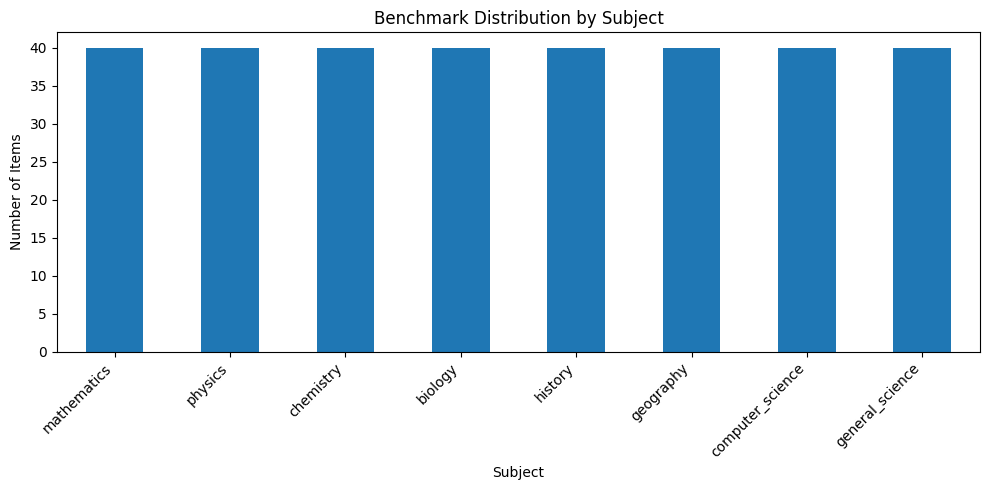

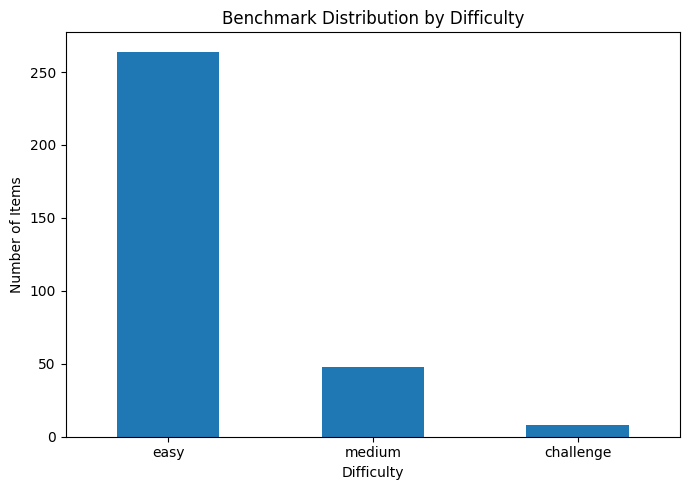

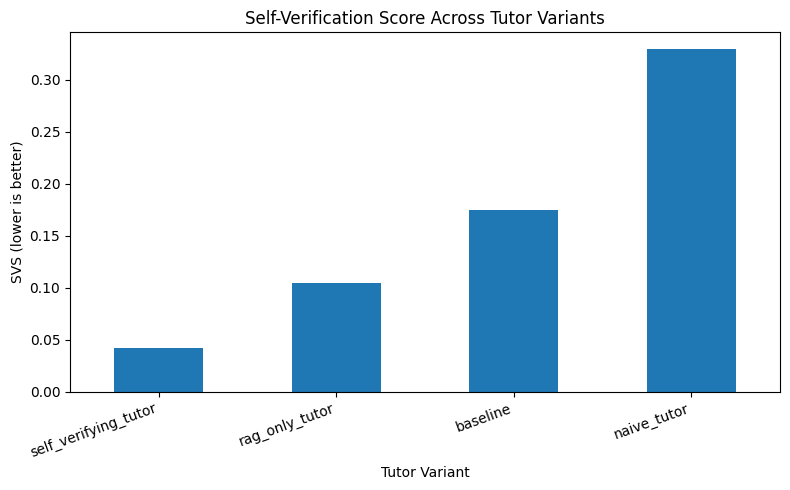

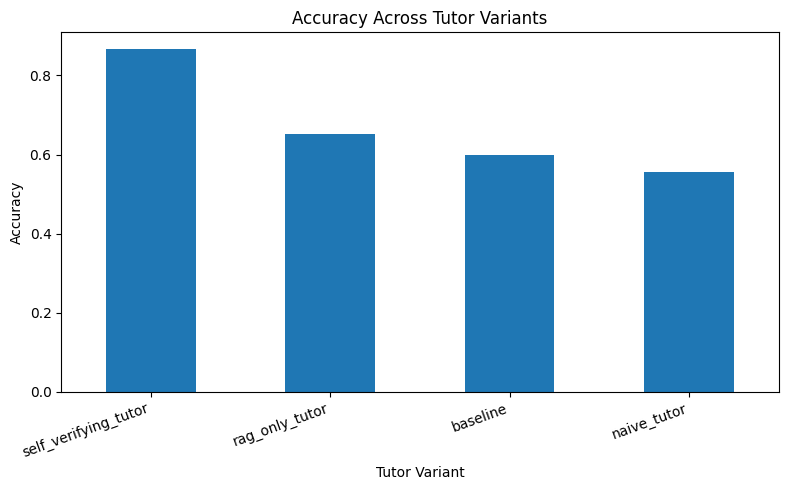

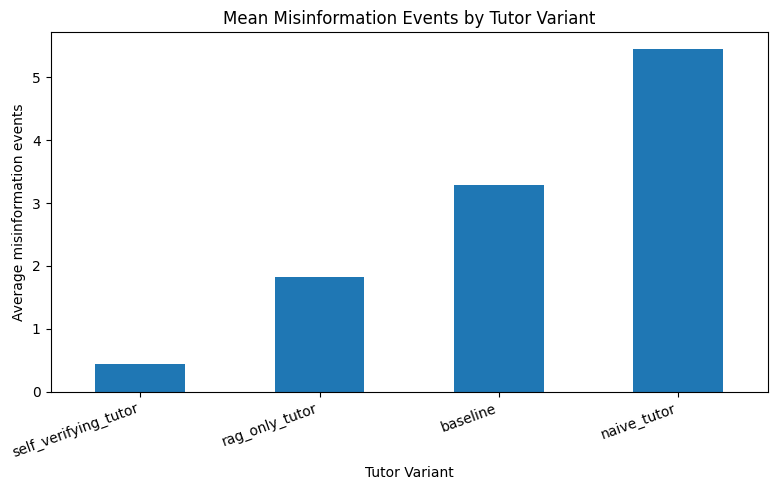

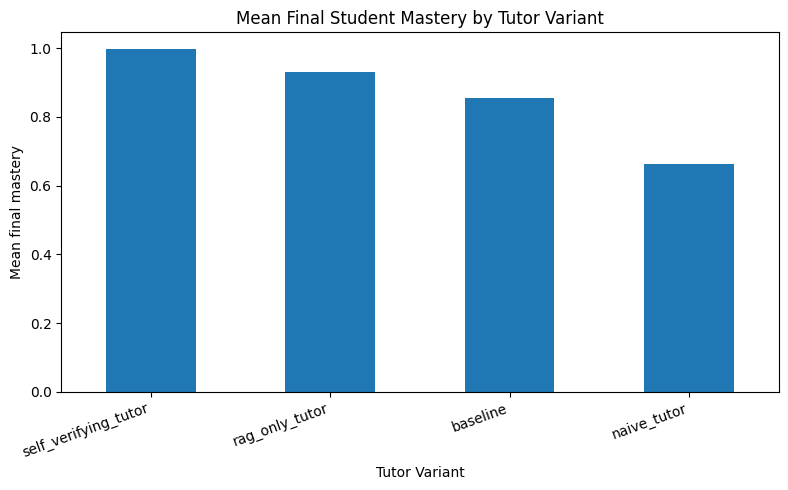

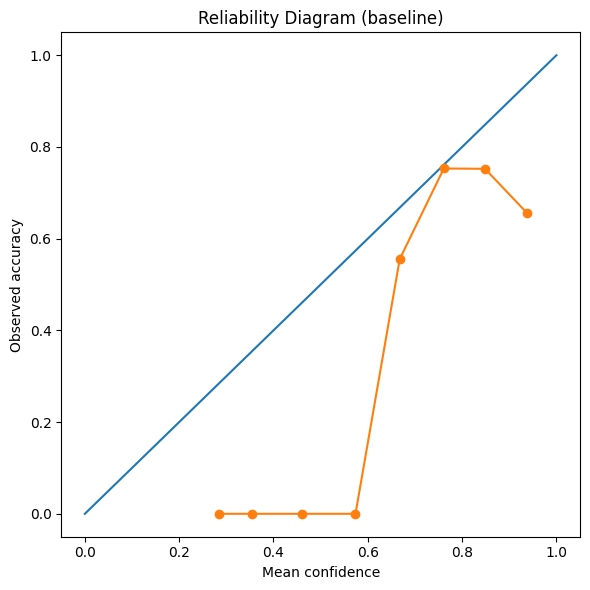

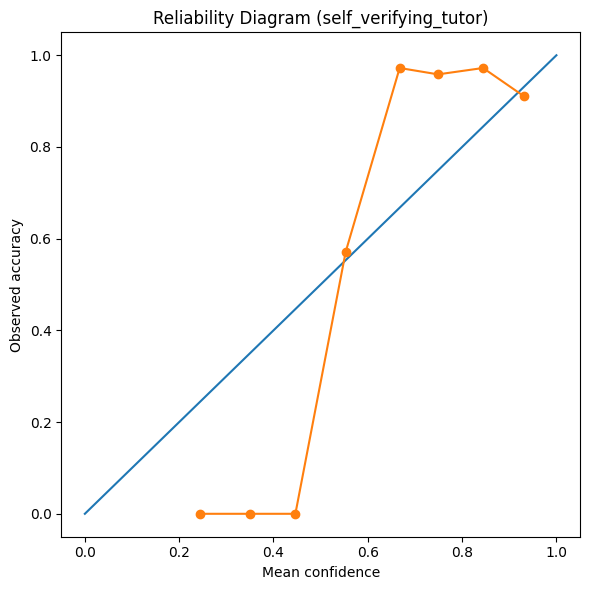

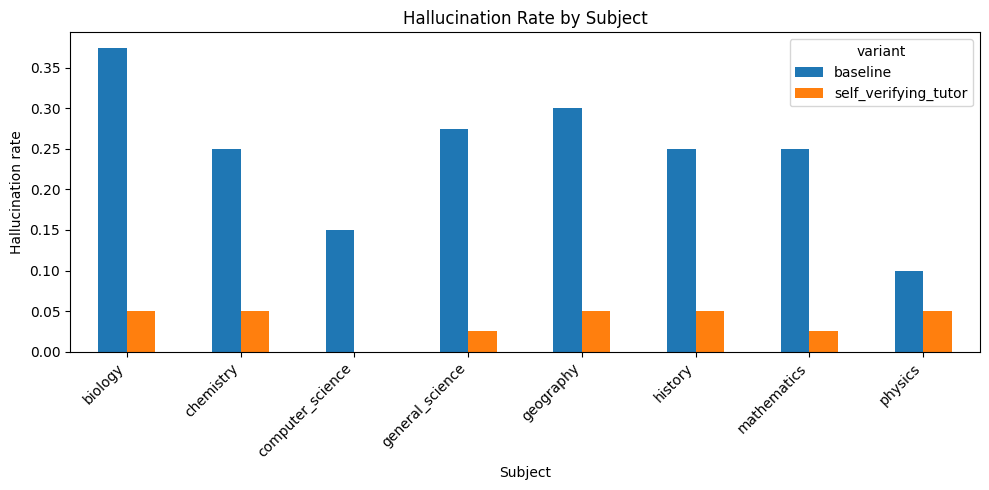

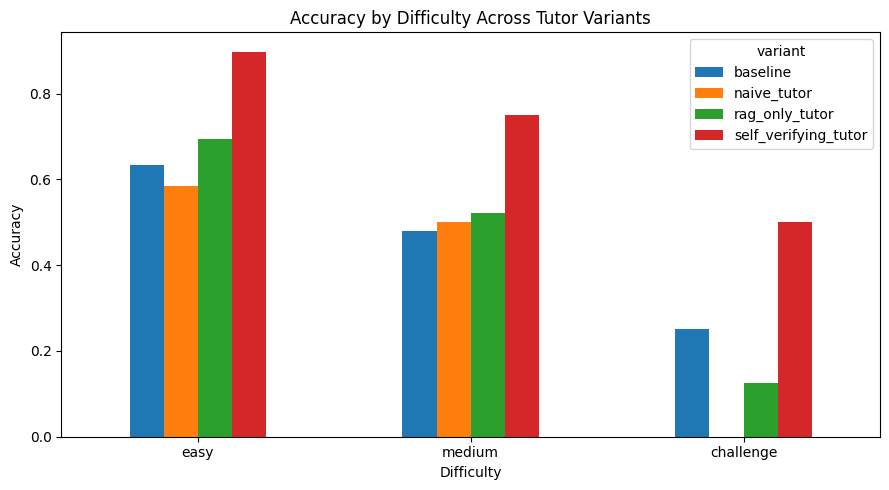

In [ ]:

subject_dist = df["subject"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,5))
subject_dist.plot(kind="bar")
plt.title("Benchmark Distribution by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Items")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_subject_distribution.png", dpi=200)
plt.show()

difficulty_dist = df["difficulty"].value_counts().reindex(["easy","medium","challenge"])
plt.figure(figsize=(7,5))
difficulty_dist.plot(kind="bar")
plt.title("Benchmark Distribution by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Number of Items")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_difficulty_distribution.png", dpi=200)
plt.show()

summary_df.sort_values("SVS").plot(x="variant", y="SVS", kind="bar", legend=False, figsize=(8,5))
plt.title("Self-Verification Score Across Tutor Variants")
plt.xlabel("Tutor Variant")
plt.ylabel("SVS (lower is better)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_svs_comparison.png", dpi=200)
plt.show()

summary_df.sort_values("accuracy", ascending=False).plot(x="variant", y="accuracy", kind="bar", legend=False, figsize=(8,5))
plt.title("Accuracy Across Tutor Variants")
plt.xlabel("Tutor Variant")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_accuracy_comparison.png", dpi=200)
plt.show()

student_impact.sort_values("mean_misinformation_events").plot(x="variant", y="mean_misinformation_events", kind="bar", legend=False, figsize=(8,5))
plt.title("Mean Misinformation Events by Tutor Variant")
plt.xlabel("Tutor Variant")
plt.ylabel("Average misinformation events")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_misinformation_events.png", dpi=200)
plt.show()

student_impact.sort_values("mean_final_mastery", ascending=False).plot(x="variant", y="mean_final_mastery", kind="bar", legend=False, figsize=(8,5))
plt.title("Mean Final Student Mastery by Tutor Variant")
plt.xlabel("Tutor Variant")
plt.ylabel("Mean final mastery")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_student_mastery.png", dpi=200)
plt.show()

for variant in ["baseline", "self_verifying_tutor"]:
    calib = calibration_tables[variant]
    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1])
    if len(calib) > 0:
        plt.plot(calib["mean_confidence"], calib["observed_accuracy"], marker="o")
    plt.title(f"Reliability Diagram ({variant})")
    plt.xlabel("Mean confidence")
    plt.ylabel("Observed accuracy")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_reliability_{variant}.png", dpi=200)
    plt.show()

pivot_h = subject_metrics[subject_metrics["variant"].isin(["baseline","self_verifying_tutor"])].pivot(index="subject", columns="variant", values="hallucination_rate").sort_index()
pivot_h.plot(kind="bar", figsize=(10,5))
plt.title("Hallucination Rate by Subject")
plt.xlabel("Subject")
plt.ylabel("Hallucination rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_subject_hallucination_baseline_vs_svt.png", dpi=200)
plt.show()

pivot_d = difficulty_metrics.pivot(index="difficulty", columns="variant", values="accuracy").reindex(["easy","medium","challenge"])
pivot_d.plot(kind="bar", figsize=(9,5))
plt.title("Accuracy by Difficulty Across Tutor Variants")
plt.xlabel("Difficulty")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_accuracy_by_difficulty_variants.png", dpi=200)
plt.show()



## 11. Export compact textual summary


In [ ]:

best_variant = summary_df.iloc[0]
summary_text = f'''
Self-Verifying Tutor - Automatic Result Summary
==============================================
Total benchmark items: {len(df)}

Best variant by SVS: {best_variant["variant"]}
Best SVS: {best_variant["SVS"]}
Best accuracy: {best_variant["accuracy"]}

Interpretation:
- Lower SVS indicates safer and better verified tutor behavior.
- Citation validity and fact validity directly improve trustworthiness.
- Self-correction reduces harmful confident hallucinations.
- Student mastery is expected to improve when misinformation events are reduced.
'''
summary_file = BASE_DIR / "automatic_result_summary.txt"
with open(summary_file, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_file)



Self-Verifying Tutor - Automatic Result Summary
Total benchmark items: 320

Best variant by SVS: self_verifying_tutor
Best SVS: 0.0425
Best accuracy: 0.8656

Interpretation:
- Lower SVS indicates safer and better verified tutor behavior.
- Citation validity and fact validity directly improve trustworthiness.
- Self-correction reduces harmful confident hallucinations.
- Student mastery is expected to improve when misinformation events are reduced.

Saved: /content/drive/MyDrive/Self_Verifying_Tutor_Benchmark/automatic_result_summary.txt



## 12. Optional hook for real APIs later


In [ ]:

# Example stub only.
# def real_tutor_call(question, options, retrieved_evidence):
#     prompt = f'''
#     You are a self-verifying educational tutor.
#     Use the evidence below, answer the question, cite the evidence IDs you used,
#     and provide a confidence score between 0 and 1.
#     Question: {question}
#     Options: {options}
#     Evidence: {retrieved_evidence.to_dict(orient="records")}
#     Return JSON with keys: answer, confidence, citations
#     '''
#     pass
